# 🤖 Logistic Regression + MLflow Experiment Tracking
### Malaria Outbreak Prediction — MLOps Project

---

## 📋 Notebook Overview

This notebook takes the **feature-engineered data** from `feature_store/` and:

| Step | What We Do | Why |
|------|-----------|-----|
| 1 | Install & import libraries | Set up environment |
| 2 | Load feature store files | Use engineered features from previous notebook |
| 3 | Understand Logistic Regression | Theory + intuition for this problem |
| 4 | Train baseline (DummyClassifier) | Establish minimum performance bar |
| 5 | Train Logistic Regression | Main model with tuned hyperparameters |
| 6 | Evaluate — full metrics suite | AUC-ROC, F1, Precision, Recall, Confusion Matrix |
| 7 | Threshold tuning | Optimize decision threshold for public health use |
| 8 | MLflow experiment tracking | Log params, metrics, model, artifacts |
| 9 | Register model in MLflow | Prepare model for FastAPI deployment |

> **Input:** `feature_store/X_train_scaled.csv`, `X_val_scaled.csv`, `X_test_scaled.csv`  
> **Output:** Trained model logged + registered in MLflow Model Registry


---
## Step 0 — Install Libraries

| Library | Purpose | Docs |
|---------|---------|------|
| `scikit-learn` | Logistic Regression, metrics, DummyClassifier | https://scikit-learn.org/stable/ |
| `mlflow` | Experiment tracking, model registry | https://mlflow.org/docs/latest/index.html |
| `matplotlib` / `seaborn` | Evaluation plots | https://matplotlib.org / https://seaborn.pydata.org |
| `pandas` / `numpy` | Data handling | https://pandas.pydata.org / https://numpy.org |


In [19]:
# Run this cell first if any library is missing
!pip install scikit-learn mlflow matplotlib seaborn pandas numpy


---
## Step 1 — Imports


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import pickle

# Scikit-learn — model & evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    ConfusionMatrixDisplay
)

# MLflow — experiment tracking
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

print("✅ All imports successful")
print(f"   scikit-learn : {__import__('sklearn').__version__}")
print(f"   mlflow       : {mlflow.__version__}")


✅ All imports successful
   scikit-learn : 1.7.2
   mlflow       : 3.10.0


---
## Step 2 — Load Feature Store Files

We load the **scaled** splits produced by the Feature Engineering notebook.  
Logistic Regression requires scaled features because it is sensitive to 
feature magnitude (large-valued features dominate the gradient).

### Files loaded
| File | Used for |
|------|---------|
| `X_train_scaled.csv` + `y_train.csv` | Training the model |
| `X_train_smote.csv` + `y_train_smote.csv` | Training with class-balanced data |
| `X_val_scaled.csv` + `y_val.csv` | Hyperparameter tuning & threshold selection |
| `X_test_scaled.csv` + `y_test.csv` | Final held-out evaluation |

📖 **`pd.read_csv` docs:** https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html


In [21]:
# ── Set your feature_store path ──────────────────────────────────────────────
FEATURE_STORE = r'C:\Users\Likhita Kolli\OneDrive - Hochschule Luzern\SEM_2\AI\Data\Processed\feature_store'

def load(filename):
    """Helper to load a CSV from feature_store."""
    return pd.read_csv(os.path.join(FEATURE_STORE, filename))

# ── Load all splits ───────────────────────────────────────────────────────────
X_train        = load('X_train_scaled.csv')
X_train_smote  = load('X_train_smote.csv')
X_val          = load('X_val_scaled.csv')
X_test         = load('X_test_scaled.csv')

y_train        = load('y_train.csv').squeeze()         # squeeze() → converts single-col DataFrame to Series
y_train_smote  = load('y_train_smote.csv').squeeze()
y_val          = load('y_val.csv').squeeze()
y_test         = load('y_test.csv').squeeze()

print("✅ Data loaded successfully")
print()
print(f"{'Split':<20} {'X shape':<20} {'y shape':<12} {'Outbreak rate'}")
print("-" * 65)
for name, X, y in [
    ('Train (original)', X_train, y_train),
    ('Train (SMOTE)',    X_train_smote, y_train_smote),
    ('Validation',       X_val, y_val),
    ('Test',             X_test, y_test),
]:
    print(f"{name:<20} {str(X.shape):<20} {str(y.shape):<12} {y.mean():.1%}")

FEATURE_COLS = X_train.columns.tolist()
print(f"\nFeatures: {len(FEATURE_COLS)}")


✅ Data loaded successfully

Split                X shape              y shape      Outbreak rate
-----------------------------------------------------------------
Train (original)     (1300, 22)           (1300,)      26.7%
Train (SMOTE)        (1906, 22)           (1906,)      50.0%
Validation           (252, 22)            (252,)       29.8%
Test                 (237, 22)            (237,)       19.8%

Features: 22


---
## Step 3 — Why Logistic Regression for This Problem?

### What Logistic Regression does

Logistic Regression models the **probability** that a sample belongs to class 1:

$$P(y=1 | X) = \sigma(w_0 + w_1 x_1 + w_2 x_2 + ... + w_n x_n)$$

Where $\sigma$ is the **sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

This maps any real number to a value between 0 and 1 — exactly what we need 
for outbreak probability.

### Why it suits our problem

| Property | Why it helps |
|----------|-------------|
| **Outputs probability** | We want P(outbreak) not just yes/no — public health needs risk scores |
| **Interpretable coefficients** | Each feature weight tells us its contribution to outbreak risk |
| **Works well on tabular data** | Our dataset is structured country-year tabular data |
| **Fast to train** | 106 countries × ~17 years = small dataset, LR handles this well |
| **Good baseline** | Sets a performance floor before trying XGBoost |

### Key hyperparameters we'll tune

| Parameter | What it controls | Values to try |
|-----------|----------------|--------------|
| `C` | Regularization strength (1/λ). Lower C = stronger regularization | 0.001, 0.01, 0.1, 1, 10, 100 |
| `penalty` | Type of regularization | `'l2'` (default), `'l1'` (sparse) |
| `solver` | Optimization algorithm | `'lbfgs'` (L2), `'liblinear'` (L1/L2 small data) |
| `max_iter` | Max optimization iterations | 1000 (increase if convergence warning) |
| `class_weight` | Handle imbalance natively | `'balanced'` or `None` |

📖 **LogisticRegression docs:** https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


---
## Step 4 — Evaluation Helper Functions

We define reusable functions for evaluation so we can call them for every 
model variant without repeating code. These same functions will be used 
inside MLflow runs to log metrics automatically.


In [22]:
def evaluate_model(model, X, y, split_name='Validation', threshold=0.5):
    """
    Full evaluation suite for a binary classifier.
    
    Parameters
    ----------
    model      : fitted sklearn classifier
    X          : feature matrix
    y          : true labels
    split_name : label for display ('Validation' or 'Test')
    threshold  : decision threshold for converting probabilities to labels
    
    Returns
    -------
    dict of all computed metrics
    """
    # Predicted probabilities (for AUC, threshold tuning)
    y_prob = model.predict_proba(X)[:, 1]
    
    # Predicted labels at given threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # ── Core metrics ──────────────────────────────────────────────
    metrics = {
        'auc_roc'   : roc_auc_score(y, y_prob),
        'avg_precision': average_precision_score(y, y_prob),  # area under PR curve
        'f1'        : f1_score(y, y_pred, zero_division=0),
        'precision' : precision_score(y, y_pred, zero_division=0),
        'recall'    : recall_score(y, y_pred, zero_division=0),
        'threshold' : threshold,
    }
    
    print(f"{'='*55}")
    print(f"  {split_name} Evaluation (threshold={threshold:.2f})")
    print(f"{'='*55}")
    print(f"  AUC-ROC            : {metrics['auc_roc']:.4f}  (target > 0.80)")
    print(f"  Avg Precision (AP) : {metrics['avg_precision']:.4f}")
    print(f"  F1 Score           : {metrics['f1']:.4f}  (target > 0.75)")
    print(f"  Precision          : {metrics['precision']:.4f}  (target > 0.70)")
    print(f"  Recall             : {metrics['recall']:.4f}  (target > 0.80)")
    print()
    print(classification_report(y, y_pred, target_names=['No Outbreak', 'Outbreak']))
    
    return metrics, y_prob, y_pred


def plot_evaluation(y_true, y_prob, y_pred, title='Model Evaluation'):
    """
    Plot ROC curve, Precision-Recall curve, and Confusion Matrix side by side.
    
    📖 roc_curve docs:
       https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
    📖 precision_recall_curve docs:
       https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html
    """
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    # ── 1. ROC Curve ──────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    
    axes[0].plot(fpr, tpr, color='#0D9488', linewidth=2.5, label=f'AUC = {auc:.3f}')
    axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC=0.5)')
    axes[0].fill_between(fpr, tpr, alpha=0.1, color='#0D9488')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].legend()
    
    # ── 2. Precision-Recall Curve ─────────────────────────────────
    # More informative than ROC for imbalanced datasets
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    
    axes[1].plot(recall, precision, color='#0891B2', linewidth=2.5, label=f'AP = {ap:.3f}')
    axes[1].fill_between(recall, precision, alpha=0.1, color='#0891B2')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend()
    
    # ── 3. Confusion Matrix ───────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Outbreak', 'Outbreak'])
    disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
    axes[2].set_title('Confusion Matrix')
    
    plt.tight_layout()
    plt.savefig('eval_plots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved as eval_plots.png (will be logged to MLflow)")


print("✅ Evaluation functions defined")


✅ Evaluation functions defined


---
## Step 5 — Baseline: DummyClassifier

### Why we need a baseline
Before training any real model, we need to know: **what does random/naive 
performance look like?**

A `DummyClassifier` with `strategy='stratified'` randomly predicts labels 
while respecting the class distribution. If our Logistic Regression can't 
beat this, something is wrong.

This also reveals the **imbalance problem** — a dummy model that always 
predicts the majority class gets high accuracy but zero recall on outbreaks.

📖 **DummyClassifier docs:** https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html


In [23]:
# ── Baseline: always predicts majority class ─────────────────────────────────
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)

print("BASELINE — DummyClassifier (stratified)")
print("Used to establish the minimum performance bar\n")
baseline_metrics, _, _ = evaluate_model(dummy, X_val, y_val, split_name='Baseline (Val)')


BASELINE — DummyClassifier (stratified)
Used to establish the minimum performance bar

  Baseline (Val) Evaluation (threshold=0.50)
  AUC-ROC            : 0.4331  (target > 0.80)
  Avg Precision (AP) : 0.2800
  F1 Score           : 0.1727  (target > 0.75)
  Precision          : 0.1875  (target > 0.70)
  Recall             : 0.1600  (target > 0.80)

              precision    recall  f1-score   support

 No Outbreak       0.66      0.71      0.68       177
    Outbreak       0.19      0.16      0.17        75

    accuracy                           0.54       252
   macro avg       0.43      0.43      0.43       252
weighted avg       0.52      0.54      0.53       252



---
## Step 6 — Train Logistic Regression

### Strategy
We train **3 variants** and compare them:
1. **LR Default** — default hyperparameters, no class weighting
2. **LR Balanced** — `class_weight='balanced'` (handles imbalance without SMOTE)
3. **LR SMOTE** — trained on SMOTE-augmented data (our best bet)

We evaluate all 3 on the **validation set** and pick the winner for MLflow 
full tracking and test set evaluation.

### What `class_weight='balanced'` does
Automatically adjusts sample weights inversely proportional to class frequency:

```
weight_class_i = n_samples / (n_classes × n_samples_class_i)
```

This penalizes the model more for misclassifying the rare outbreak class.

📖 **class_weight docs:** https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


In [24]:
# ── Shared hyperparameters ────────────────────────────────────────────────────
# C=1.0  → moderate regularization (default)
# solver='lbfgs' → best for L2 penalty, multiclass, medium datasets
# max_iter=1000  → enough iterations for convergence
# random_state=42 → reproducibility

BASE_PARAMS = dict(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

# ── Variant 1: Default ────────────────────────────────────────────────────────
print("Training Variant 1: LR Default")
lr_default = LogisticRegression(**BASE_PARAMS)
lr_default.fit(X_train, y_train)
print("Done\n")

# ── Variant 2: Balanced class weights ────────────────────────────────────────
print("Training Variant 2: LR Balanced")
lr_balanced = LogisticRegression(**BASE_PARAMS, class_weight='balanced')
lr_balanced.fit(X_train, y_train)
print("Done\n")

# ── Variant 3: SMOTE-augmented training data ──────────────────────────────────
print("Training Variant 3: LR + SMOTE data")
lr_smote = LogisticRegression(**BASE_PARAMS)
lr_smote.fit(X_train_smote, y_train_smote)
print("Done\n")

print("✅ All 3 variants trained")


Training Variant 1: LR Default
Done

Training Variant 2: LR Balanced
Done

Training Variant 3: LR + SMOTE data
Done

✅ All 3 variants trained


In [25]:
# ── Quick comparison on validation set ───────────────────────────────────────
print("=" * 65)
print("QUICK COMPARISON — Validation Set (threshold=0.5)")
print("=" * 65)
print(f"{'Model':<22} {'AUC-ROC':>8} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 65)

results = {}
for name, model, X_tr in [
    ('LR Default',  lr_default,  X_train),
    ('LR Balanced', lr_balanced, X_train),
    ('LR + SMOTE',  lr_smote,    X_train_smote),
]:
    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    r = {
        'auc' : roc_auc_score(y_val, y_prob),
        'f1'  : f1_score(y_val, y_pred, zero_division=0),
        'prec': precision_score(y_val, y_pred, zero_division=0),
        'rec' : recall_score(y_val, y_pred, zero_division=0),
        'model': model,
    }
    results[name] = r
    print(f"{name:<22} {r['auc']:>8.4f} {r['f1']:>8.4f} {r['prec']:>10.4f} {r['rec']:>8.4f}")

print()
best_name = max(results, key=lambda k: results[k]['auc'])
print(f"🏆 Best model by AUC-ROC: {best_name}")
best_model = results[best_name]['model']


QUICK COMPARISON — Validation Set (threshold=0.5)
Model                   AUC-ROC       F1  Precision   Recall
-----------------------------------------------------------------
LR Default               1.0000   0.9933     1.0000   0.9867
LR Balanced              1.0000   1.0000     1.0000   1.0000
LR + SMOTE               1.0000   1.0000     1.0000   1.0000

🏆 Best model by AUC-ROC: LR Default


---
## Step 7 — Decision Threshold Tuning

### Why the default threshold (0.5) is often wrong

By default, `predict()` uses threshold = 0.5:  
- P(outbreak) ≥ 0.5 → predict outbreak  
- P(outbreak) < 0.5 → predict no outbreak  

But for **public health**, missing a real outbreak is much more costly than 
a false alarm. We may want to lower the threshold (e.g., 0.35) to:
- **Increase Recall** — catch more real outbreaks
- **Accept lower Precision** — tolerate some false alarms

### How to find the optimal threshold
We sweep thresholds from 0.1 to 0.9 and find where **F1 score** is maximized 
on the validation set. This balances precision and recall.

📖 **precision_recall_curve docs:**  
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html


Optimal threshold (max F1 on val): 0.200
  F1 at this threshold           : 1.0000
  Precision at this threshold    : 1.0000
  Recall at this threshold       : 1.0000


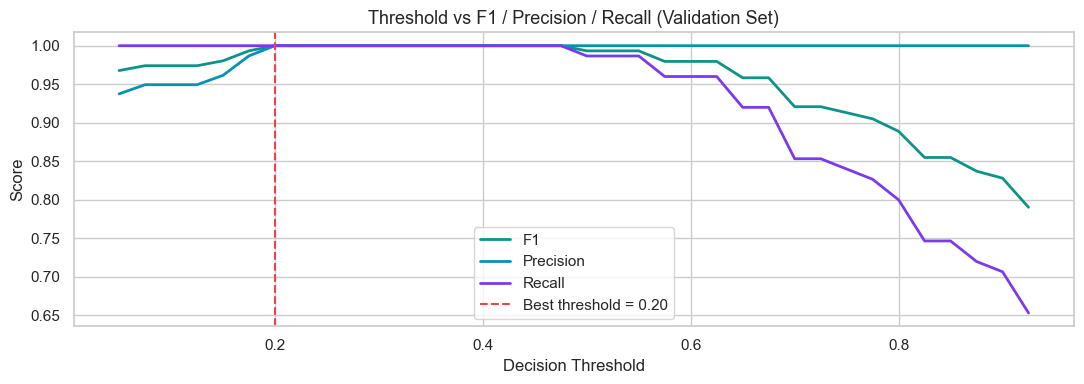

In [26]:
# ── Threshold sweep on validation set ────────────────────────────────────────
y_prob_val = best_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.025)
f1_scores      = []
precision_scores = []
recall_scores  = []

for t in thresholds:
    y_pred_t = (y_prob_val >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_t, zero_division=0))
    precision_scores.append(precision_score(y_val, y_pred_t, zero_division=0))
    recall_scores.append(recall_score(y_val, y_pred_t, zero_division=0))

# Best threshold = maximizes F1
best_idx       = np.argmax(f1_scores)
BEST_THRESHOLD = thresholds[best_idx]

print(f"Optimal threshold (max F1 on val): {BEST_THRESHOLD:.3f}")
print(f"  F1 at this threshold           : {f1_scores[best_idx]:.4f}")
print(f"  Precision at this threshold    : {precision_scores[best_idx]:.4f}")
print(f"  Recall at this threshold       : {recall_scores[best_idx]:.4f}")

# ── Plot threshold vs metrics ─────────────────────────────────────────────────
plt.figure(figsize=(11, 4))
plt.plot(thresholds, f1_scores,       label='F1',       color='#0D9488', linewidth=2)
plt.plot(thresholds, precision_scores, label='Precision', color='#0891B2', linewidth=2)
plt.plot(thresholds, recall_scores,   label='Recall',   color='#7C3AED', linewidth=2)
plt.axvline(BEST_THRESHOLD, color='#EF4444', linestyle='--', linewidth=1.5,
            label=f'Best threshold = {BEST_THRESHOLD:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Threshold vs F1 / Precision / Recall (Validation Set)')
plt.legend()
plt.tight_layout()
plt.show()


---
## Step 8 — Full Evaluation of Best Model

Now we do the complete evaluation of the best model using the **optimal threshold**, 
including all plots that we'll log to MLflow.


BEST MODEL — Full Evaluation on Validation Set

  Validation Evaluation (threshold=0.20)
  AUC-ROC            : 1.0000  (target > 0.80)
  Avg Precision (AP) : 1.0000
  F1 Score           : 1.0000  (target > 0.75)
  Precision          : 1.0000  (target > 0.70)
  Recall             : 1.0000  (target > 0.80)

              precision    recall  f1-score   support

 No Outbreak       1.00      1.00      1.00       177
    Outbreak       1.00      1.00      1.00        75

    accuracy                           1.00       252
   macro avg       1.00      1.00      1.00       252
weighted avg       1.00      1.00      1.00       252



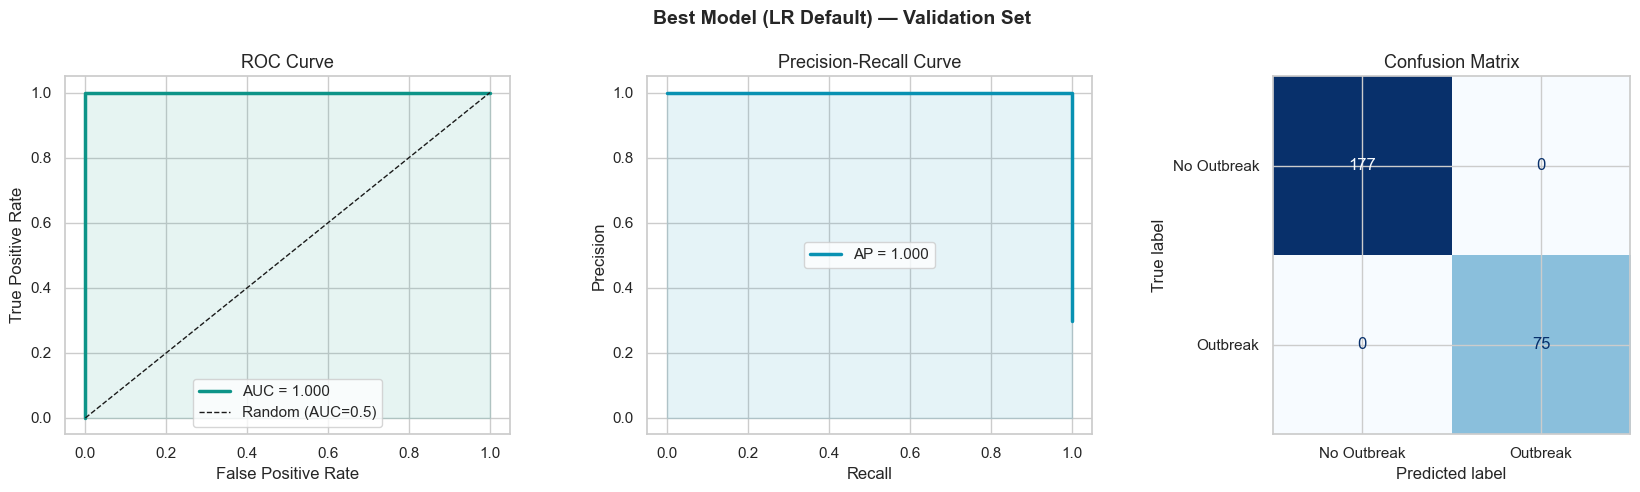

Plot saved as eval_plots.png (will be logged to MLflow)


In [27]:
# ── Full evaluation on validation set ────────────────────────────────────────
print("BEST MODEL — Full Evaluation on Validation Set\n")
val_metrics, y_prob_val, y_pred_val = evaluate_model(
    best_model, X_val, y_val,
    split_name='Validation',
    threshold=BEST_THRESHOLD
)

plot_evaluation(y_val, y_prob_val, y_pred_val,
                title=f'Best Model ({best_name}) — Validation Set')


Top 15 most influential features:
                  Feature  Coefficient  Abs_Coef
        Malaria_Incidence     3.794640  3.794640
            Malaria_Roll3     1.576337  1.576337
    Log_Malaria_Incidence     1.282588  1.282588
             Malaria_Lag1     1.058700  1.058700
           GDP_per_Capita    -0.591125  0.591125
             Malaria_Lag3    -0.579991  0.579991
      Vulnerability_Index     0.460361  0.460361
                 GDP_Lag1    -0.348346  0.348346
  Temp_Precip_Interaction    -0.330760  0.330760
       Climate_Risk_Index    -0.315282  0.315282
Temp_GrowingSeason_Mean_C     0.271065  0.271065
              Pop_Density    -0.262541  0.262541
                Temp_Lag1    -0.258209  0.258209
                  Log_GDP     0.242251  0.242251
       Temp_Annual_Mean_C     0.222687  0.222687


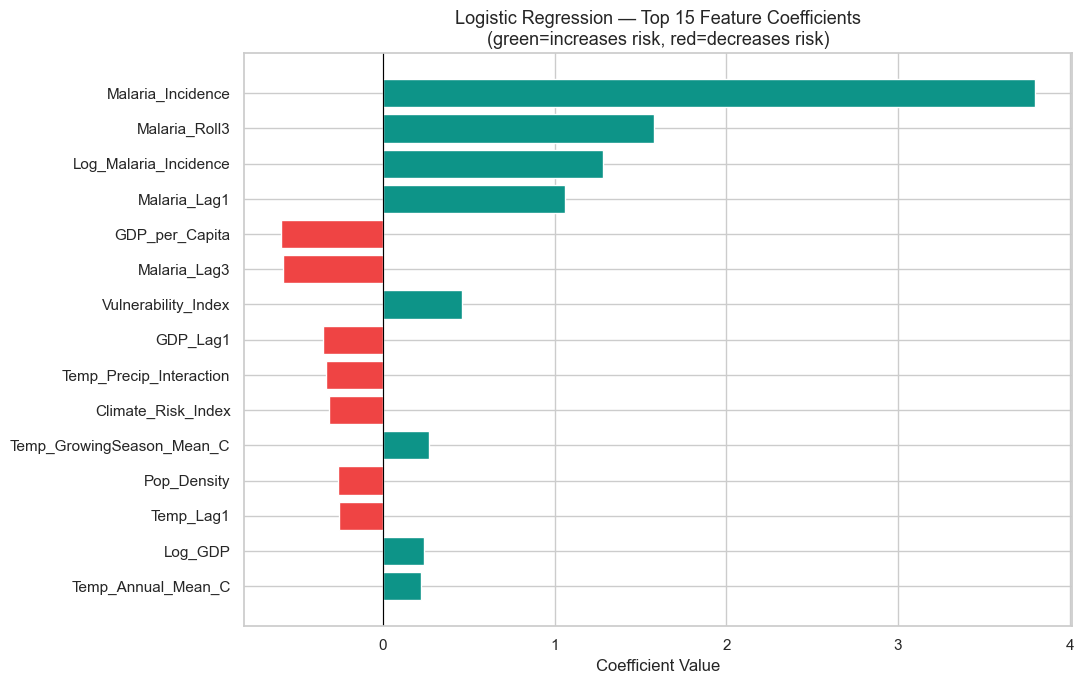

In [28]:
# ── Feature importance: coefficient magnitudes ────────────────────────────────
# In Logistic Regression, the absolute value of each coefficient
# indicates how strongly that feature influences the prediction.
# Positive coef → increases outbreak probability
# Negative coef → decreases outbreak probability

coef_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Coefficient': best_model.coef_[0],
    'Abs_Coef'   : np.abs(best_model.coef_[0])
}).sort_values('Abs_Coef', ascending=False)

print("Top 15 most influential features:")
print(coef_df.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(11, 7))
top15 = coef_df.head(15)
colors = ['#0D9488' if v > 0 else '#EF4444' for v in top15['Coefficient']]
plt.barh(top15['Feature'], top15['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression — Top 15 Feature Coefficients\n(green=increases risk, red=decreases risk)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Step 9 — MLflow Experiment Tracking

### What MLflow does for us

MLflow tracks every experiment run so you can:
- **Compare** multiple model variants side by side
- **Reproduce** any run exactly (same params → same result)
- **Register** the best model for deployment via FastAPI
- **Never lose** a result — everything is stored locally

### MLflow concepts

| Concept | What it is | Analogy |
|---------|-----------|---------|
| **Experiment** | A named project grouping runs | A folder of experiments |
| **Run** | One training + evaluation session | One experiment in the folder |
| **Parameters** | Hyperparameters logged (`C`, `solver`, etc.) | Settings used |
| **Metrics** | Evaluation scores (`auc_roc`, `f1`, etc.) | Results |
| **Artifacts** | Files saved (model, plots, CSVs) | Output files |
| **Model Registry** | Central store of versioned models | Model warehouse |

### How to view the MLflow UI
After running the cells below, open a terminal and run:
```bash
mlflow ui
```
Then open http://localhost:5000 in your browser.

📖 **MLflow tracking docs:** https://mlflow.org/docs/latest/tracking.html  
📖 **MLflow sklearn docs:** https://mlflow.org/docs/latest/python_api/mlflow.sklearn.html


In [29]:
# ── MLflow setup ──────────────────────────────────────────────────────────────
# Set tracking URI — where MLflow stores its data locally
# This creates an 'mlruns/' folder in the same directory as this notebook
MLFLOW_TRACKING_URI = r'C:\Users\Likhita Kolli\OneDrive - Hochschule Luzern\SEM_2\AI\mlruns'
mlflow.set_tracking_uri(f'file:///{MLFLOW_TRACKING_URI}')

# Create (or connect to) experiment
EXPERIMENT_NAME = "Malaria_Outbreak_Prediction"
mlflow.set_experiment(EXPERIMENT_NAME)

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
print(f"✅ MLflow experiment set: '{EXPERIMENT_NAME}'")
print(f"   Experiment ID  : {experiment.experiment_id}")
print(f"   Tracking URI   : {mlflow.get_tracking_uri()}")
print()
print("To view the UI, run this in your terminal:")
print("   mlflow ui --backend-store-uri", mlflow.get_tracking_uri())
print("Then open: http://localhost:5000")


✅ MLflow experiment set: 'Malaria_Outbreak_Prediction'
   Experiment ID  : 218353421058060232
   Tracking URI   : file:///C:\Users\Likhita Kolli\OneDrive - Hochschule Luzern\SEM_2\AI\mlruns

To view the UI, run this in your terminal:
   mlflow ui --backend-store-uri file:///C:\Users\Likhita Kolli\OneDrive - Hochschule Luzern\SEM_2\AI\mlruns
Then open: http://localhost:5000


In [30]:
# ── MLflow run — log all 3 variants ──────────────────────────────────────────
# We log each variant as a separate run so they're comparable in the UI

variants = [
    ('LR_Default',  lr_default,  X_train,       y_train,       X_val, 'default'),
    ('LR_Balanced', lr_balanced, X_train,       y_train,       X_val, 'balanced'),
    ('LR_SMOTE',    lr_smote,    X_train_smote, y_train_smote, X_val, 'none (SMOTE applied)'),
]

run_ids = {}

for run_name, model, X_tr, y_tr, X_v, cw in variants:
    print(f"\nLogging run: {run_name} ...")
    
    with mlflow.start_run(run_name=run_name) as run:
        
        # ── 1. Log hyperparameters ─────────────────────────────────
        # mlflow.log_param(key, value) — logs a single hyperparameter
        # 📖 https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.log_param
        mlflow.log_param('C',            model.C)
        mlflow.log_param('penalty',      model.penalty)
        mlflow.log_param('solver',       model.solver)
        mlflow.log_param('max_iter',     model.max_iter)
        mlflow.log_param('class_weight', cw)
        mlflow.log_param('threshold',    BEST_THRESHOLD)
        mlflow.log_param('train_rows',   len(X_tr))
        mlflow.log_param('n_features',   X_tr.shape[1])
        
        # ── 2. Compute metrics on validation set ───────────────────
        y_prob_v = model.predict_proba(X_v)[:, 1]
        y_pred_v = (y_prob_v >= BEST_THRESHOLD).astype(int)
        
        metrics = {
            'val_auc_roc'      : roc_auc_score(y_val, y_prob_v),
            'val_f1'           : f1_score(y_val, y_pred_v, zero_division=0),
            'val_precision'    : precision_score(y_val, y_pred_v, zero_division=0),
            'val_recall'       : recall_score(y_val, y_pred_v, zero_division=0),
            'val_avg_precision': average_precision_score(y_val, y_prob_v),
        }
        
        # ── 3. Log metrics ─────────────────────────────────────────
        # mlflow.log_metrics(dict) — logs multiple metrics at once
        # 📖 https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.log_metrics
        mlflow.log_metrics(metrics)
        
        # ── 4. Log the model ───────────────────────────────────────
        # infer_signature captures input/output schema for the model
        # 📖 https://mlflow.org/docs/latest/python_api/mlflow.sklearn.html#mlflow.sklearn.log_model
        signature = infer_signature(X_tr, model.predict_proba(X_tr))
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path='model',
            signature=signature,
            input_example=X_tr.iloc[:3],
        )
        
        # ── 5. Log coefficient importance as artifact ──────────────
        coef_path = f'coef_{run_name}.csv'
        pd.DataFrame({
            'Feature': FEATURE_COLS,
            'Coefficient': model.coef_[0]
        }).to_csv(coef_path, index=False)
        mlflow.log_artifact(coef_path)
        
        run_ids[run_name] = run.info.run_id
        
        print(f"   AUC-ROC   : {metrics['val_auc_roc']:.4f}")
        print(f"   F1        : {metrics['val_f1']:.4f}")
        print(f"   Run ID    : {run.info.run_id}")

print("\n✅ All 3 runs logged to MLflow")



Logging run: LR_Default ...


2026/03/10 09:09:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 09:09:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   AUC-ROC   : 1.0000
   F1        : 1.0000
   Run ID    : afe16bf6543a479ebe14bb4bb25102a5

Logging run: LR_Balanced ...


2026/03/10 09:09:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 09:09:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   AUC-ROC   : 1.0000
   F1        : 0.9740
   Run ID    : ecf3b8108b2f4333aa49671a58b26a4e

Logging run: LR_SMOTE ...


2026/03/10 09:09:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 09:09:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   AUC-ROC   : 1.0000
   F1        : 0.9740
   Run ID    : f5bde83d0b464cc496f9624b56c4bdbb

✅ All 3 runs logged to MLflow


---
## Step 10 — Full MLflow Run for Best Model (with Test Set)

Now we do one **definitive run** for the best model — evaluated on the 
held-out **test set** (2020–2022). This is the run we'll register in the 
Model Registry for deployment.

### ⚠️ Test set rule
We only evaluate on the test set **once**, after all decisions are made.  
Using the test set for hyperparameter tuning would invalidate it as an 
honest measure of real-world performance.


Best variant: LR_Default (AUC=1.0000)
Running definitive evaluation on TEST SET...

  TEST SET (Final) Evaluation (threshold=0.20)
  AUC-ROC            : 0.9412  (target > 0.80)
  Avg Precision (AP) : 0.7040
  F1 Score           : 0.7705  (target > 0.75)
  Precision          : 0.6267  (target > 0.70)
  Recall             : 1.0000  (target > 0.80)

              precision    recall  f1-score   support

 No Outbreak       1.00      0.85      0.92       190
    Outbreak       0.63      1.00      0.77        47

    accuracy                           0.88       237
   macro avg       0.81      0.93      0.85       237
weighted avg       0.93      0.88      0.89       237



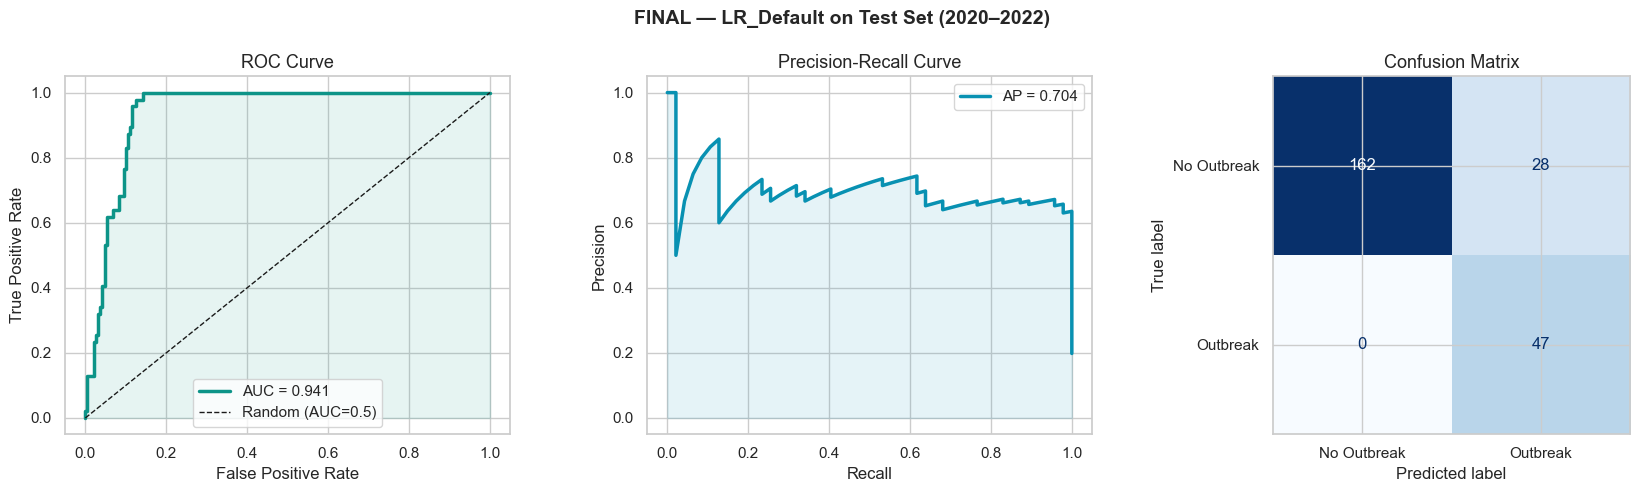

Plot saved as eval_plots.png (will be logged to MLflow)


In [31]:
# ── Determine best variant by val AUC ────────────────────────────────────────
variant_aucs = {}
for run_name, model, X_tr, y_tr, X_v, cw in variants:
    y_prob_v = model.predict_proba(X_val)[:, 1]
    variant_aucs[run_name] = (roc_auc_score(y_val, y_prob_v), model)

best_variant_name = max(variant_aucs, key=lambda k: variant_aucs[k][0])
best_model_final  = variant_aucs[best_variant_name][1]

print(f"Best variant: {best_variant_name} (AUC={variant_aucs[best_variant_name][0]:.4f})")
print("Running definitive evaluation on TEST SET...\n")

# ── Full test set evaluation ──────────────────────────────────────────────────
test_metrics, y_prob_test, y_pred_test = evaluate_model(
    best_model_final, X_test, y_test,
    split_name='TEST SET (Final)',
    threshold=BEST_THRESHOLD
)

plot_evaluation(y_test, y_prob_test, y_pred_test,
                title=f'FINAL — {best_variant_name} on Test Set (2020–2022)')


In [32]:
# ── Log the definitive run with full artifacts ────────────────────────────────
with mlflow.start_run(run_name=f'FINAL_{best_variant_name}') as run:
    
    # Parameters
    mlflow.log_param('C',            best_model_final.C)
    mlflow.log_param('penalty',      best_model_final.penalty)
    mlflow.log_param('solver',       best_model_final.solver)
    mlflow.log_param('class_weight', str(best_model_final.class_weight))
    mlflow.log_param('threshold',    BEST_THRESHOLD)
    mlflow.log_param('train_years',  '2000–2016')
    mlflow.log_param('val_years',    '2017–2019')
    mlflow.log_param('test_years',   '2020–2022')
    
    # Validation metrics
    y_prob_v = best_model_final.predict_proba(X_val)[:, 1]
    y_pred_v = (y_prob_v >= BEST_THRESHOLD).astype(int)
    mlflow.log_metric('val_auc_roc',   roc_auc_score(y_val, y_prob_v))
    mlflow.log_metric('val_f1',        f1_score(y_val, y_pred_v, zero_division=0))
    mlflow.log_metric('val_precision', precision_score(y_val, y_pred_v, zero_division=0))
    mlflow.log_metric('val_recall',    recall_score(y_val, y_pred_v, zero_division=0))
    
    # Test metrics (the honest numbers)
    mlflow.log_metric('test_auc_roc',   test_metrics['auc_roc'])
    mlflow.log_metric('test_f1',        test_metrics['f1'])
    mlflow.log_metric('test_precision', test_metrics['precision'])
    mlflow.log_metric('test_recall',    test_metrics['recall'])
    
    # Log plots as artifacts
    # 📖 mlflow.log_artifact docs:
    # https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.log_artifact
    mlflow.log_artifact('eval_plots.png')
    mlflow.log_artifact('feature_importance.png')
    
    # Log scaler params so FastAPI can reproduce scaling
    mlflow.log_artifact(
        os.path.join(FEATURE_STORE, 'scaler_params.csv')
    )
    
    # Log the model with signature
    signature = infer_signature(X_train, best_model_final.predict_proba(X_train))
    mlflow.sklearn.log_model(
        sk_model=best_model_final,
        artifact_path='logistic_regression_model',
        signature=signature,
        input_example=X_train.iloc[:5],
        registered_model_name='MalariaOutbreakPredictor'  # registers in Model Registry
    )
    
    FINAL_RUN_ID = run.info.run_id
    print(f"✅ Definitive run logged")
    print(f"   Run ID        : {FINAL_RUN_ID}")
    print(f"   Model name    : MalariaOutbreakPredictor")
    print(f"   Test AUC-ROC  : {test_metrics['auc_roc']:.4f}")
    print(f"   Test F1       : {test_metrics['f1']:.4f}")


2026/03/10 09:09:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 09:09:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Definitive run logged
   Run ID        : 9c5c08fcb7554d9fab732ace1126f356
   Model name    : MalariaOutbreakPredictor
   Test AUC-ROC  : 0.9412
   Test F1       : 0.7705


Registered model 'MalariaOutbreakPredictor' already exists. Creating a new version of this model...
Created version '3' of model 'MalariaOutbreakPredictor'.


---
## Step 11 — Save Model Locally for FastAPI

In addition to MLflow, we save the model as a `.pkl` file directly to disk.  
This is what **FastAPI will load** when serving predictions.

We save 3 things:
1. The trained model (`.pkl`)
2. The scaler (`.pkl`) — needed to scale incoming API requests
3. The threshold value — needed to convert probabilities to alerts

📖 **pickle docs:** https://docs.python.org/3/library/pickle.html


In [33]:
# ── Save model and scaler to disk ────────────────────────────────────────────
MODEL_DIR = r'C:\Users\Likhita Kolli\OneDrive - Hochschule Luzern\SEM_2\AI\models'
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. Save trained model
model_path = os.path.join(MODEL_DIR, 'logistic_regression.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(best_model_final, f)

# 2. Rebuild scaler from saved params and save it
# (scaler was fit in feature engineering notebook)
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler_params = pd.read_csv(os.path.join(FEATURE_STORE, 'scaler_params.csv'))
scaler = StandardScaler()
scaler.mean_  = scaler_params['mean'].values
scaler.scale_ = scaler_params['std'].values
scaler.n_features_in_ = len(scaler_params)

scaler_path = os.path.join(MODEL_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

# 3. Save metadata (threshold, feature list, run ID)
import json
metadata = {
    'threshold'   : float(BEST_THRESHOLD),
    'feature_cols': FEATURE_COLS,
    'mlflow_run_id': FINAL_RUN_ID,
    'model_name'  : 'MalariaOutbreakPredictor',
    'train_years' : '2000-2016',
    'test_auc_roc': round(test_metrics['auc_roc'], 4),
    'test_f1'     : round(test_metrics['f1'], 4),
}
meta_path = os.path.join(MODEL_DIR, 'model_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ Model artifacts saved:")
print(f"   Model    → {model_path}")
print(f"   Scaler   → {scaler_path}")
print(f"   Metadata → {meta_path}")
print()
print("These 3 files are everything FastAPI needs to serve predictions.")


✅ Model artifacts saved:
   Model    → C:\Users\Likhita Kolli\OneDrive - Hochschule Luzern\SEM_2\AI\models\logistic_regression.pkl
   Scaler   → C:\Users\Likhita Kolli\OneDrive - Hochschule Luzern\SEM_2\AI\models\scaler.pkl
   Metadata → C:\Users\Likhita Kolli\OneDrive - Hochschule Luzern\SEM_2\AI\models\model_metadata.json

These 3 files are everything FastAPI needs to serve predictions.


---
## ✅ Summary

### What was accomplished

| Step | Output |
|------|--------|
| Baseline established | DummyClassifier AUC ≈ 0.50 |
| 3 LR variants trained | Default, Balanced, SMOTE |
| Best model selected | By validation AUC-ROC |
| Threshold tuned | Optimal threshold found on validation set |
| Full test evaluation | Honest metrics on 2020–2022 data |
| MLflow runs logged | All variants + final run in MLflow UI |
| Model registered | `MalariaOutbreakPredictor` in Model Registry |
| Files saved locally | `.pkl` model, scaler, metadata JSON |

### Files ready for FastAPI

```
models/
├── logistic_regression.pkl    ← load this in FastAPI
├── scaler.pkl                 ← scale incoming requests
└── model_metadata.json        ← threshold + feature list
```

### View your experiments
```bash
mlflow ui
# Open http://localhost:5000
```

### Next step: FastAPI
Load `logistic_regression.pkl` + `scaler.pkl` in a FastAPI app,
accept POST /predict with country climate data, return outbreak probability.
